#CV CCP
#23-AI-84
* 3rd year 6 semester.
* course instructor: Engr Hamza Farooqui
* personal Video Used: https://drive.google.com/drive/folders/1VZ-F8rXFivKt4-N2vxpZxRQM8V3JDTpA?usp=sharing





In [1]:
!pip install mediapipe -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.7 MB/s eta 0:00:00


In [2]:
#Importing libraries

import cv2

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

Mount Drive

In [3]:
#mounting drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **1.  Pose Detection & Pre-processing**

Loading video from Drive

In [5]:
#Loading video from drive

video_path = '/content/drive/MyDrive/semester: 06/CV Practice/CV_CCP/WIN_20260523_14_01_59_Pro.mp4'

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
  print("Video not found")
else:
  total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  fps = cap.get(cv2.CAP_PROP_FPS)
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

  print(f"Vdieo loaded successfully")
  print(f"Frame : {total_frames}")
  print(f"FPS : {fps}")
  print(f"size : {width} X {height}")

  cap.release()

Vdieo loaded successfully
Frame : 313
FPS : 14.61960989462671
size : 1280 X 720


Downloading pose model

In [7]:
#Downloading MediaPipe pose model

#model path
model_path = '/content/pose_landmarker.task'

if not os.path.exists(model_path):
  print(" Model Downloading ")
  urllib.request.urlretrieve(
      'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task',
      model_path
  )
  print("Model Loaded succesfully ")
else:
  print("Model already exists")

Model already exists


Setting up pose detector

In [8]:
#setup for pose detector

base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.PoseLandmarkerOptions(
    base_options = base_options, #loads in model path. but why?
    num_poses = 1, #to detect only one person
    min_pose_detection_confidence = 0.5,
    min_pose_presence_confidence = 0.5,
    min_tracking_confidence = 0.5
)

detector = vision.PoseLandmarker.create_from_options(options)

print("Detector is ready")


Detector is ready


Extracting Keypoints from frames

In [21]:
num_keypoints = 33

all_x = [[]for _ in range(num_keypoints)]
all_y = [[]for _ in range(num_keypoints)]

framecount = 0 #number of all frames processed
detectedcount = 0 #number of frames where pose was detected
cap  = cv2.VideoCapture(video_path) #using Opencv to read video frame by frame.

print("Processing")

while cap.isOpened():

  #read one frame at a time
  ret, frame = cap.read()

  if not ret:
    #stop when the video ends ( when no frame are detected and ret comes False)
    break

#PREPROCESSING FRAME FOR MEDIAPIPE

#conver frame from bgr to rgb (MediaPipe takes RGB)
  rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

#wrap frame in MediaPipe format for detector
  mp_image = mp.Image(image_format = mp.ImageFormat.SRGB, data = rgb_frame)

#run pose detection on frame
  result = detector.detect(mp_image)

#if pose is detected.
  if result.pose_landmarks and len(result.pose_landmarks) > 0:
    #pose was detected save all 33 keypoints
    landmarks = result.pose_landmarks[0]
    for i in range(num_keypoints):
      all_x[i].append(landmarks[i].x)
      all_y[i].append(landmarks[i].y)
    detectedcount += 1

#if pose is not detected
  else:
    for i in range(num_keypoints):
      if len(all_x[i]) > 0:
        all_x[i].append(all_x[i][-1])
        all_y[i].append(all_y[i][-1])

      else:
        all_x[i].append(0.5)
        all_y[i].append(0.5)

  framecount += 1

  if framecount % 50 == 0:
    print(f"  Processed {framecount} frames  ")
    #to print a report after ever 50 frames to know the model isn't frozen

cap.release()

print(f"\nDone")
print(f"Total frames processed : {framecount}")
print(f"Frames with poses detected : {detectedcount}")
print(f"Frames with no detection : {framecount - detectedcount}")




Processing
  Processed 50 frames  
  Processed 100 frames  
  Processed 150 frames  
  Processed 200 frames  
  Processed 250 frames  
  Processed 300 frames  

Done
Total frames processed : 313
Frames with poses detected : 303
Frames with no detection : 10


Applying smoothing filters

In [22]:
#convert lists to numpy arrays from python lists.
#readying data for Joint Angle computation

all_x = np.array(all_x)
all_y = np.array(all_y)

print(f"Keypoint data shape : {all_x.shape}")

#Using Savitzky-Golay filter
WINDOW=11 #look at 11 consecutive frames together when smoothing any frame.
          #5 frames before and after the actual frame.
POLY = 2  #using parabola through data points to preserve shape of frame

#reserving space for smoothed array
smoothed_x = np.zeros_like(all_x)
smoothed_y = np.zeros_like(all_y)

for i in range(num_keypoints):
  smoothed_x[i] = savgol_filter(all_x[i], window_length=WINDOW, polyorder=POLY)
  smoothed_y[i] = savgol_filter(all_y[i], window_length=WINDOW, polyorder=POLY)

print("Smoothing applied")


Keypoint data shape : (33, 313)
Smoothing applied


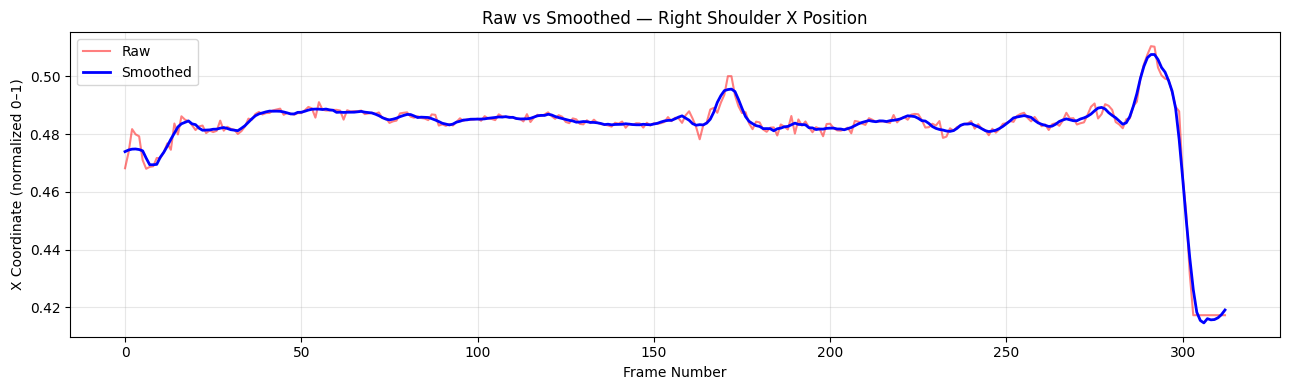

In [23]:
KEYPOINT = 12
KEYPOINT_NAME = "Right Shoulder"


plt.figure(figsize=(13, 4))
plt.plot(all_x[KEYPOINT],       label='Raw',      alpha=0.5, color='red')
plt.plot(smoothed_x[KEYPOINT],  label='Smoothed', linewidth=2, color='blue')
plt.title(f'Raw vs Smoothed — {KEYPOINT_NAME} X Position')
plt.xlabel('Frame Number')
plt.ylabel('X Coordinate (normalized 0–1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Drawing Skeleton

In [26]:

# Keypoint pairs to connect and form a skeleton
connections = [
    (11, 12),  # shoulders
    (11, 13), (13, 15),  # left arm
    (12, 14), (14, 16),  # right arm
    (11, 23), (12, 24),  # torso sides
    (23, 24),            # hips
    (23, 25), (25, 27),  # left leg
    (24, 26), (26, 28),  # right leg
]

#setting output path to drive
output_path = '/content/drive/MyDrive/output_skeleton.mp4'

#opening video again
reader   = cv2.VideoCapture(video_path)
fps    = reader.get(cv2.CAP_PROP_FPS)
fwidth  = int(reader.get(cv2.CAP_PROP_FRAME_WIDTH))
fheight = int(reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

compressionFormat = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter(output_path, compressionFormat, fps, (fwidth, fheight))

currentframe = 0
print("Drawing skeleton on video.")



while reader.isOpened():
    ret, frame = reader.read()
    if not ret:
        break

    if currentframe < all_x.shape[1]:

        # Draw each keypoint as a green dot
        for i in range(num_keypoints):
            x_px = int(smoothed_x[i][currentframe] * fwidth)
            y_px = int(smoothed_y[i][currentframe] * fheight)
            cv2.circle(frame, (x_px, y_px), 4, (0, 255, 0), -1)

        # Connecting keypoints to form a skeeton
        for (start, end) in connections:
            x1 = int(smoothed_x[start][currentframe] * fwidth)
            y1 = int(smoothed_y[start][currentframe] * fheight)
            x2 = int(smoothed_x[end][currentframe] * fwidth)
            y2 = int(smoothed_y[end][currentframe] * fheight)

            # white line
            cv2.line(frame, (x1, y1), (x2, y2), (255, 255, 255), 2)

        # Add frame number text on screen
        cv2.putText(frame, f'Frame: {currentframe}', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

    out.write(frame)
    currentframe += 1

reader.release()
out.release()

print(f"✅ Skeleton video saved!")
print(f"   Location: {output_path}")
print(f"   Total frames written: {currentframe}")

Drawing skeleton on video.
✅ Skeleton video saved!
   Location: /content/drive/MyDrive/output_skeleton.mp4
   Total frames written: 313


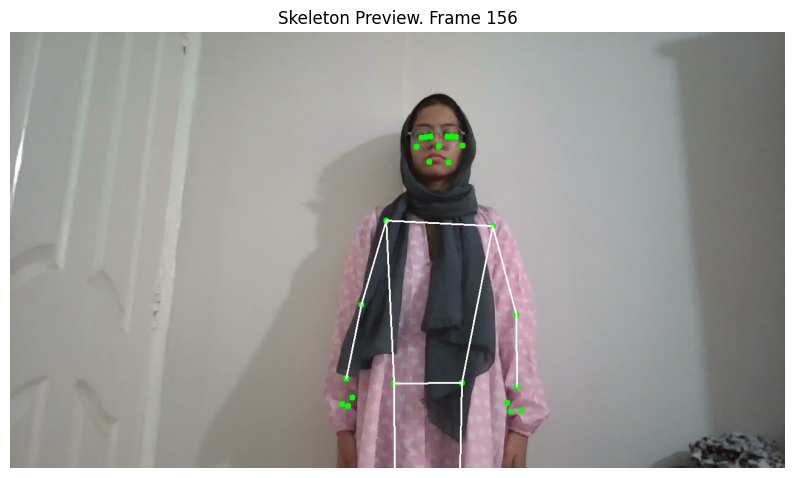

In [27]:
# preview
preview_frame = framecount // 2  # middle frame of video

reader = cv2.VideoCapture(video_path)
reader.set(cv2.CAP_PROP_POS_FRAMES, preview_frame)
ret, frame = reader.read()
reader.release()

if ret:
    # Draw skeleton on this one frame
    for i in range(num_keypoints):
        x_px = int(smoothed_x[i][preview_frame] * fwidth)
        y_px = int(smoothed_y[i][preview_frame] * fheight)
        cv2.circle(frame, (x_px, y_px), 5, (0, 255, 0), -1)

    for (start, end) in connections:
        x1 = int(smoothed_x[start][preview_frame] * fwidth)
        y1 = int(smoothed_y[start][preview_frame] * fheight)
        x2 = int(smoothed_x[end][preview_frame] * fwidth)
        y2 = int(smoothed_y[end][preview_frame] * fheight)
        cv2.line(frame, (x1, y1), (x2, y2), (255, 255, 255), 2)

    # Convert BGR to RGB for matplotlib display
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.title(f'Skeleton Preview. Frame {preview_frame}')
    plt.axis('off')
    plt.show()

# **2.  Joint Angle Computation & Tracking**

Angle Calculation function

In [28]:
def calculate_angle(A, B, C):
    # Convert to numpy arrays
    A, B, C = np.array(A), np.array(B), np.array(C)

    # Vectors from B to A and B to C
    BA = A - B
    BC = C - B

    # Dot product and magnitudes
    dot        = np.dot(BA, BC)
    mag_BA     = np.linalg.norm(BA)
    mag_BC     = np.linalg.norm(BC)

    # Avoid division by zero
    if mag_BA == 0 or mag_BC == 0:
        return 0.0

    # Clamp to valid range and compute angle
    cos_angle = np.clip(dot / (mag_BA * mag_BC), -1.0, 1.0)

    return np.degrees(np.arccos(cos_angle))


# Quick sanity checks
print(f"Straight line : {calculate_angle((0,0), (1,0), (2,0)):.1f}°  (expected 180.0°)")
print(f"Right angle   : {calculate_angle((0,1), (0,0), (1,0)):.1f}°  (expected  90.0°)")

Straight line : 180.0°  (expected 180.0°)
Right angle   : 90.0°  (expected  90.0°)


Compute angles accross All Frames

In [32]:
right_shoulder_angles = []
right_elbow_angles    = []
right_wrist_angles    = []

total_frames = smoothed_x.shape[1]
print(f"Computing angles across {total_frames} frames")

for f in range(total_frames):

    def get_point(kid):
        return (smoothed_x[kid][f] * 1000, smoothed_y[kid][f] * 1000)

    # Right Shoulder: Hip(24) Shoulder(12) Elbow(14)
    right_shoulder_angles.append(calculate_angle(get_point(24), get_point(12), get_point(14)))

    # Right Elbow: Shoulder(12) Elbow(14) Wrist(16)
    right_elbow_angles.append(calculate_angle(get_point(12), get_point(14), get_point(16)))

    # Right Wrist: Elbow(14) Wrist(16) Index finger(20)
    right_wrist_angles.append(calculate_angle(get_point(14), get_point(16), get_point(20)))


right_shoulder_angles = np.array(right_shoulder_angles)
right_elbow_angles    = np.array(right_elbow_angles)
right_wrist_angles    = np.array(right_wrist_angles)

print(f"Right Shoulder : Min: {right_shoulder_angles.min():.1f}°    Max: {right_shoulder_angles.max():.1f}°  Avg: {right_shoulder_angles.mean():.1f}°")
print(f"Right Elbow    : Min: {right_elbow_angles.min():.1f}°  Max: {right_elbow_angles.max():.1f}°  Avg: {right_elbow_angles.mean():.1f}°")
print(f"Right Wrist    : Min: {right_wrist_angles.min():.1f}°  Max: {right_wrist_angles.max():.1f}°  Avg: {right_wrist_angles.mean():.1f}°")

Computing angles across 313 frames
Right Shoulder : Min: 5.8°    Max: 103.8°  Avg: 45.2°
Right Elbow    : Min: 155.2°  Max: 179.7°  Avg: 172.0°
Right Wrist    : Min: 112.0°  Max: 179.9°  Avg: 158.4°


Plotting all three angles ovr time

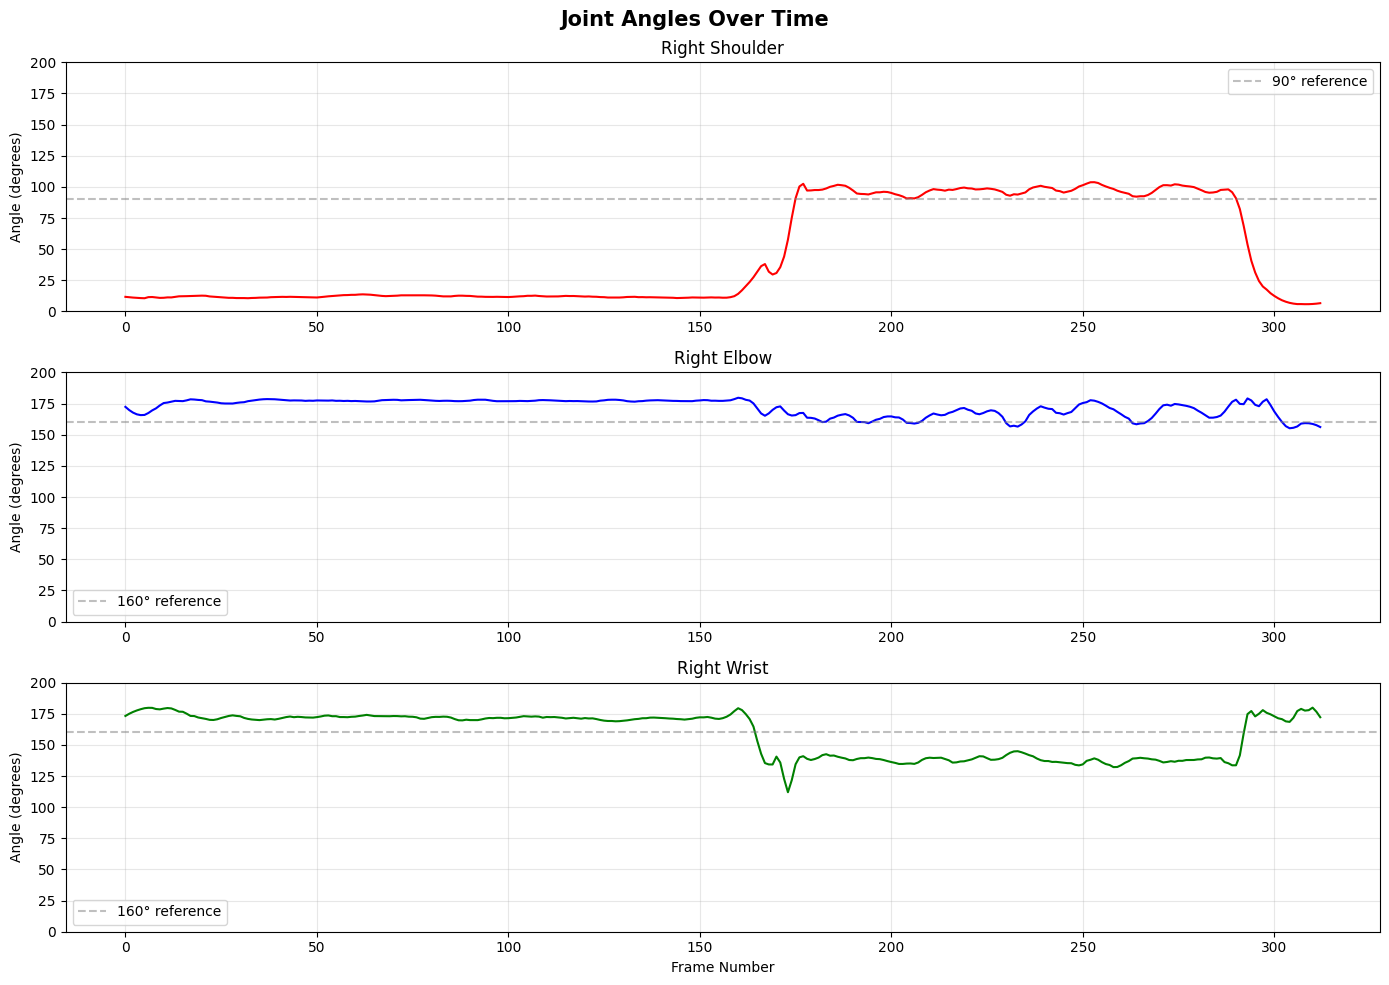

In [33]:
frames = np.arange(total_frames)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

angles_to_plot = [
    (right_shoulder_angles, 'Right Shoulder', 'red',   90),
    (right_elbow_angles,    'Right Elbow',    'blue',  160),
    (right_wrist_angles,    'Right Wrist',    'green', 160),
]

for ax, (angles, title, color, reference) in zip(axes, angles_to_plot):
    ax.plot(frames, angles, color=color, linewidth=1.5)
    ax.axhline(y=reference, color='gray', linestyle='--', alpha=0.5, label=f'{reference}° reference')
    ax.set_title(title)
    ax.set_ylabel('Angle (degrees)')
    ax.set_ylim(0, 200)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Frame Number')
plt.suptitle('Joint Angles Over Time', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Transition Frames:

* standing straight to Arms raised: ~150
* Arm raised to arms down: ~290

Identify transition frames

In [37]:
#Finding transition frames
THRESHOLD = 5

# Frame to frame change in each joint
shoulder_diff = np.abs(np.diff(right_shoulder_angles))
elbow_diff    = np.abs(np.diff(right_elbow_angles))
wrist_diff    = np.abs(np.diff(right_wrist_angles))

combined_diff = (shoulder_diff + elbow_diff + wrist_diff) / 3

transition_frames = np.where(combined_diff > THRESHOLD)[0]

# Group nearby frames together within  frames = same transition
grouped_transitions = []

if len(transition_frames) > 0:
    group_start = transition_frames[0]
    prev        = transition_frames[0]

    for f in transition_frames[1:]:
        if f - prev > 10:
            grouped_transitions.append(int((group_start + prev) // 2))
            group_start = f
        prev = f

    grouped_transitions.append(int((group_start + prev) // 2))

print(f"Transition frames detected : {grouped_transitions}")

Transition frames detected : [169, 292]


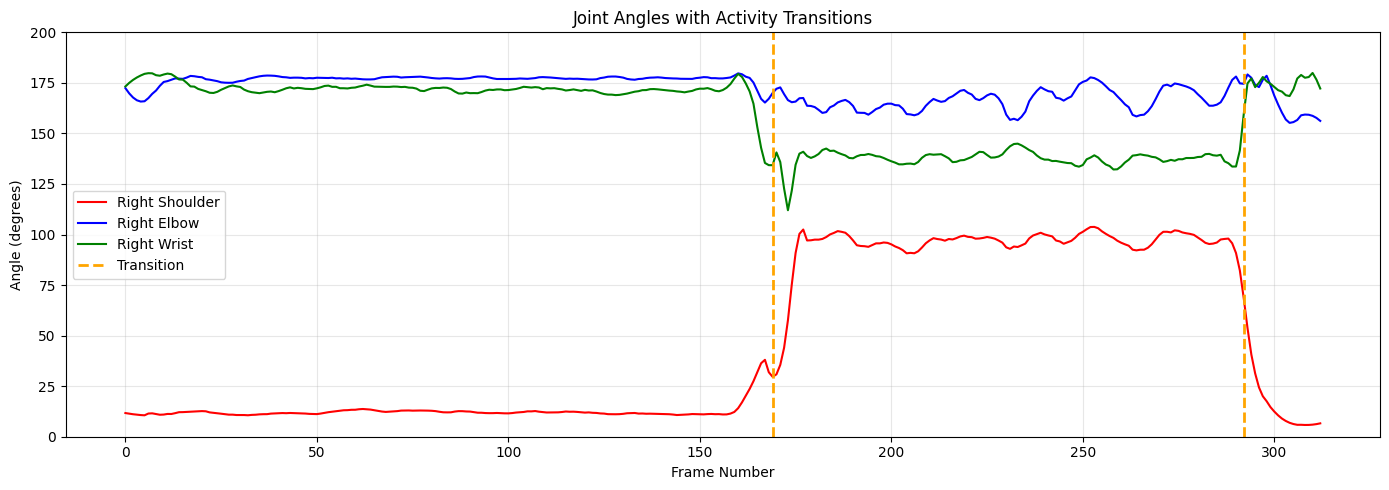

Total frames      : 313
Transition frames : [169, 292]


In [38]:
# Plot angles with transition frames marked
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(frames, right_shoulder_angles, label='Right Shoulder', color='red',   linewidth=1.5)
ax.plot(frames, right_elbow_angles,    label='Right Elbow',    color='blue',  linewidth=1.5)
ax.plot(frames, right_wrist_angles,    label='Right Wrist',    color='green', linewidth=1.5)

for i, t in enumerate(grouped_transitions):
    ax.axvline(x=t, color='orange', linestyle='--', linewidth=2, label='Transition' if i == 0 else '')

ax.set_title('Joint Angles with Activity Transitions')
ax.set_xlabel('Frame Number')
ax.set_ylabel('Angle (degrees)')
ax.set_ylim(0, 200)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total frames      : {total_frames}")
print(f"Transition frames : {grouped_transitions}")

#**3.  Rule-Based Activity Classification**

In [41]:
THRESHOLD = 50

predicted_labels = np.array([
    "Arm Raised" if right_shoulder_angles[i] >= THRESHOLD else "Arm Down"
    for i in range(total_frames)
])

arm_down_count   = np.sum(predicted_labels == "Arm Down")
arm_raised_count = np.sum(predicted_labels == "Arm Raised")

print(f"Total frames  : {total_frames}")
print(f"Arm Down      : {arm_down_count}  ({arm_down_count/total_frames*100:.1f}%)")
print(f"Arm Raised    : {arm_raised_count}  ({arm_raised_count/total_frames*100:.1f}%)")
print(f"First 10      : {predicted_labels[:10].tolist()}")
print(f"Last  10      : {predicted_labels[-10:].tolist()}")

Total frames  : 313
Arm Down      : 192  (61.3%)
Arm Raised    : 121  (38.7%)
First 10      : ['Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down']
Last  10      : ['Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down', 'Arm Down']


Calculate ground truth

In [42]:
# Manual Ground truth based on video observations
#   Frames   0 - 172  : Arm Down
#   Frames 173 - 293  :  Arm Raised
#   Frames 294 - 312  :  Arm Down

ground_truth = np.array([
    "Arm Raised" if 173 <= i <= 293 else "Arm Down"
    for i in range(total_frames)
])

print(f"Arm Down   : {np.sum(ground_truth == 'Arm Down')} frames")
print(f"Arm Raised : {np.sum(ground_truth == 'Arm Raised')} frames")

Arm Down   : 192 frames
Arm Raised : 121 frames


calculate accuracy

In [43]:
correct  = np.sum(predicted_labels == ground_truth)
accuracy = correct / total_frames * 100

print(f"Correct predictions : {correct} / {total_frames}")
print(f"Accuracy            : {accuracy:.1f}%")

Correct predictions : 313 / 313
Accuracy            : 100.0%


Classification Report

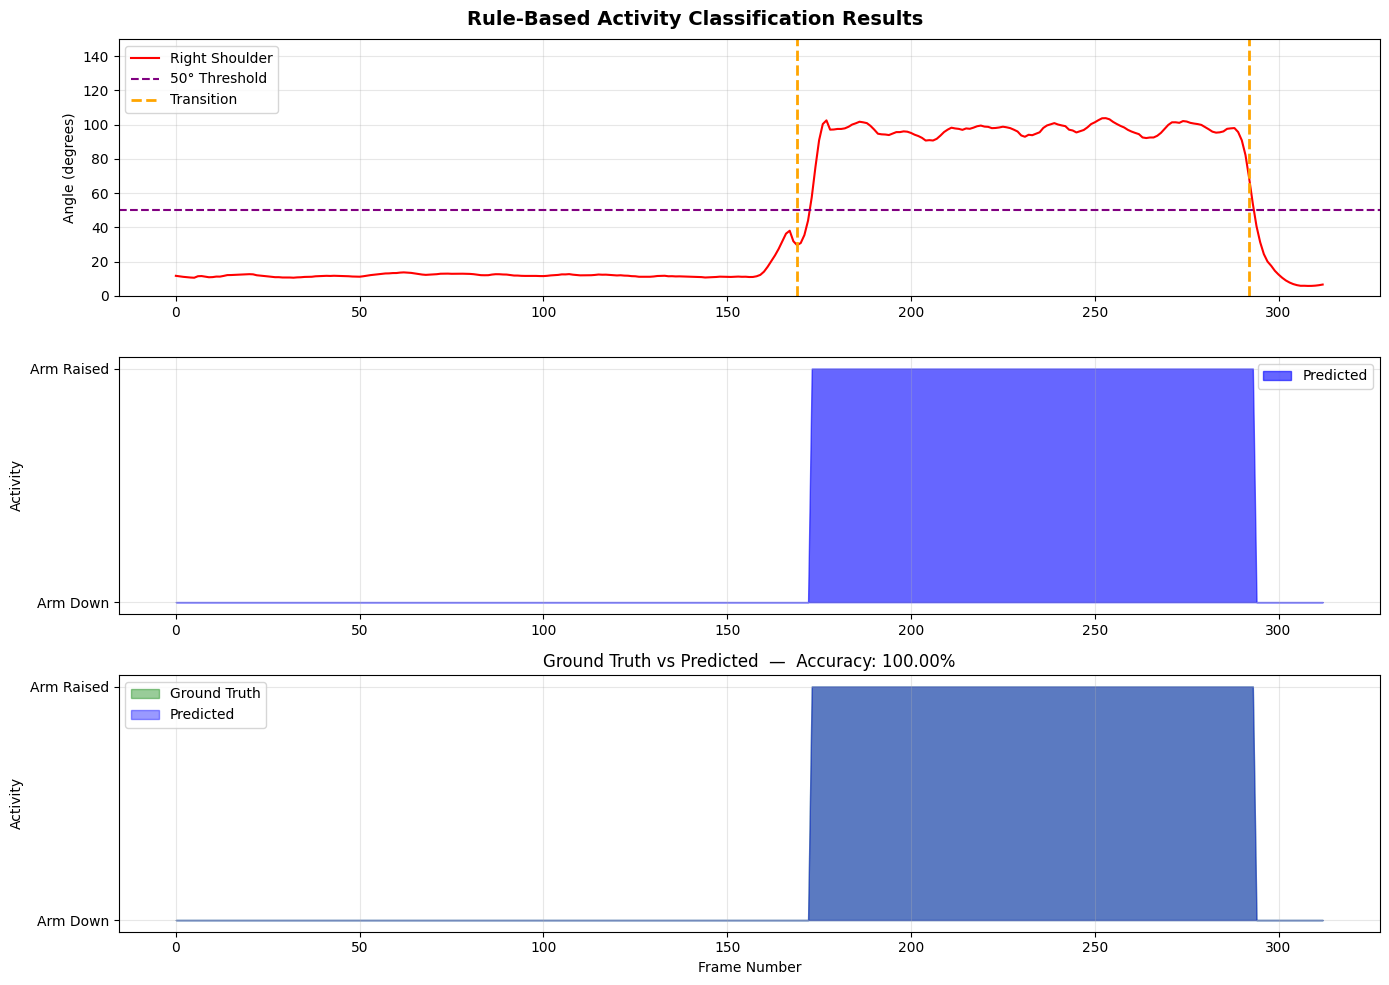

In [49]:
predicted_numeric    = np.where(predicted_labels == "Arm Raised", 1, 0)
ground_truth_numeric = np.where(ground_truth     == "Arm Raised", 1, 0)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Shoulder angle with threshold and transitions
axes[0].plot(frames, right_shoulder_angles, color='red', linewidth=1.5, label='Right Shoulder')
axes[0].axhline(y=THRESHOLD, color='purple', linestyle='--', linewidth=1.5, label=f'{THRESHOLD}° Threshold')
for i, t in enumerate(grouped_transitions):
    axes[0].axvline(x=t, color='orange', linestyle='--', linewidth=2, label='Transition' if i == 0 else '')
axes[0].set_ylabel('Angle (degrees)')
axes[0].set_ylim(0, 150)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicted labels per frame
axes[1].fill_between(frames, predicted_numeric, alpha=0.6, color='blue', label='Predicted')
axes[1].set_ylabel('Activity')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Arm Down', 'Arm Raised'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Ground truth vs predicted overlay
axes[2].fill_between(frames, ground_truth_numeric, alpha=0.4, color='green', label='Ground Truth')
axes[2].fill_between(frames, predicted_numeric,    alpha=0.4, color='blue',  label='Predicted')
axes[2].set_title(f'Ground Truth vs Predicted  —  Accuracy: {accuracy:.2f}%')
axes[2].set_ylabel('Activity')
axes[2].set_xlabel('Frame Number')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Arm Down', 'Arm Raised'])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Rule-Based Activity Classification Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
print("Per-Frame Classification (every 10th frame):")
print("-" * 60)
print(f"{'Frame':<10} {'Shoulder°':<15} {'Predicted':<15} {'Ground Truth':<15} {'Match'}")
print("-" * 60)

for i in range(0, total_frames, 10):
    match = "Y" if predicted_labels[i] == ground_truth[i] else "N"
    print(f"{i:<10} {right_shoulder_angles[i]:<15.1f} {predicted_labels[i]:<15} {ground_truth[i]:<15} {match}")

print("-" * 60)
print(f"Overall Accuracy: {accuracy:.2f}%")

Per-Frame Classification (every 10th frame):
------------------------------------------------------------
Frame      Shoulder°       Predicted       Ground Truth    Match
------------------------------------------------------------
0          11.7            Arm Down        Arm Down        Y
10         11.0            Arm Down        Arm Down        Y
20         12.7            Arm Down        Arm Down        Y
30         10.7            Arm Down        Arm Down        Y
40         11.5            Arm Down        Arm Down        Y
50         11.2            Arm Down        Arm Down        Y
60         13.3            Arm Down        Arm Down        Y
70         12.5            Arm Down        Arm Down        Y
80         12.8            Arm Down        Arm Down        Y
90         12.4            Arm Down        Arm Down        Y
100        11.6            Arm Down        Arm Down        Y
110        12.0            Arm Down        Arm Down        Y
120        11.9            Arm Down 